In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/zalando-research/fashionmnist


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
FASHION-MNIST DATASET SUMMARY
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)

Image Height : 28
Image Width  : 28
Number of Classes : 10

Class Labels
0 --> T-shirt/Top
1 --> Trouser
2 --> Pullover
3 --> Dress
4 --> Coat
5 --> Sandal
6 --> Shirt
7 --> Sneaker
8 --> Bag
9 --> Ankle Boot

Pixel Statistics
------------------------
Minimum Pixel Value : 0
Maximum Pixel Value : 255
Mean Pixel Value    : 72.94035223214286
Standard Deviation  : 90.02118235130519


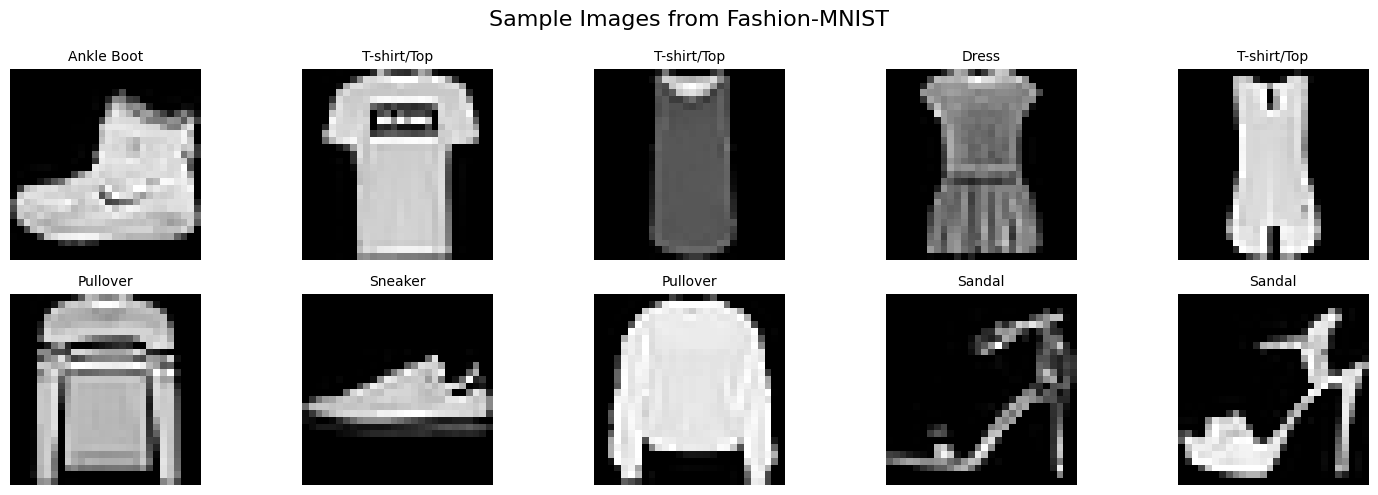

/tmp/ipykernel_58/3570894320.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


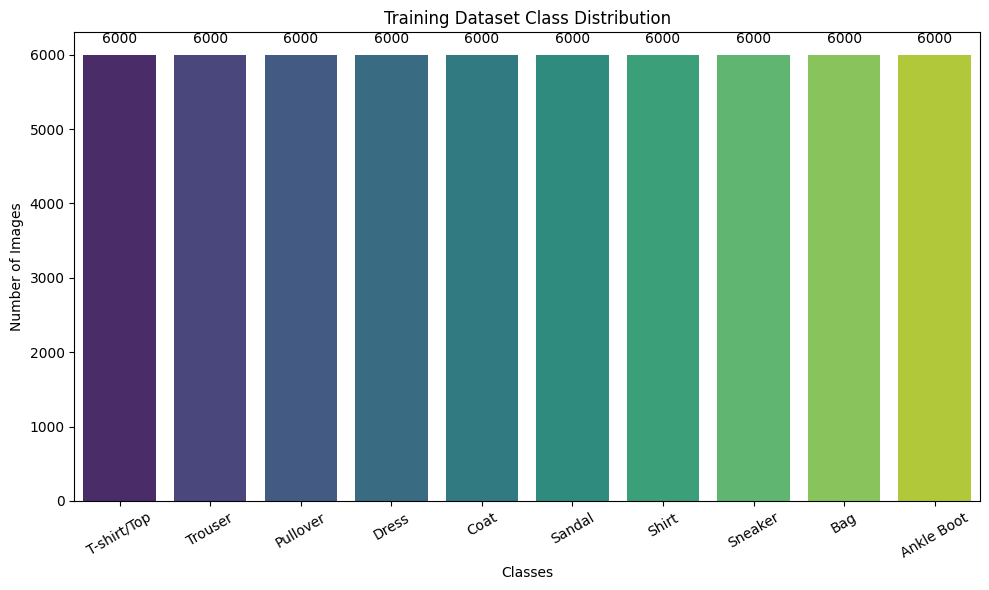


Training Class Distribution
----------------------------------------
T-shirt/Top     : 6000
Trouser         : 6000
Pullover        : 6000
Dress           : 6000
Coat            : 6000
Sandal          : 6000
Shirt           : 6000
Sneaker         : 6000
Bag             : 6000
Ankle Boot      : 6000
----------------------------------------

Dataset Successfully Loaded.


In [3]:
# ============================================================
# TASK 1 : DATASET EXPLORATION
# Fashion-MNIST Dataset
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist

# ------------------------------------------------------------
# Create folder for saving all diagrams
# ------------------------------------------------------------

os.makedirs("diagrams", exist_ok=True)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# ------------------------------------------------------------
# Class Names
# ------------------------------------------------------------

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------

print("="*60)
print("FASHION-MNIST DATASET SUMMARY")
print("="*60)

print(f"Training Images : {X_train.shape}")
print(f"Training Labels : {y_train.shape}")

print(f"Testing Images  : {X_test.shape}")
print(f"Testing Labels  : {y_test.shape}")

print()

print(f"Image Height : {X_train.shape[1]}")
print(f"Image Width  : {X_train.shape[2]}")

print(f"Number of Classes : {len(class_names)}")

print()

print("Class Labels")

for i, name in enumerate(class_names):
    print(f"{i} --> {name}")

print("="*60)

# ------------------------------------------------------------
# Pixel Statistics
# ------------------------------------------------------------

print("\nPixel Statistics")
print("------------------------")

print("Minimum Pixel Value :", X_train.min())
print("Maximum Pixel Value :", X_train.max())
print("Mean Pixel Value    :", X_train.mean())
print("Standard Deviation  :", X_train.std())

# ------------------------------------------------------------
# Display 10 Sample Images
# ------------------------------------------------------------

plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)

plt.tight_layout()

plt.savefig(
    "diagrams/task1_sample_images.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Class Distribution
# ------------------------------------------------------------

unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,6))

sns.barplot(
    x=[class_names[i] for i in unique],
    y=counts,
    palette="viridis"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

for i, count in enumerate(counts):
    plt.text(i, count+150, str(count), ha='center')

plt.tight_layout()

plt.savefig(
    "diagrams/task1_class_distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Print Class Distribution
# ------------------------------------------------------------

print("\nTraining Class Distribution")
print("-"*40)

for i in range(len(class_names)):
    print(f"{class_names[i]:15s} : {counts[i]}")

print("-"*40)

print("\nDataset Successfully Loaded.")

TASK 2 : DATA PREPROCESSING

Shapes Before Preprocessing
----------------------------------------
X_train : (60000, 28, 28)
X_test  : (10000, 28, 28)
y_train : (60000,)
y_test  : (10000,)

Shapes After Preprocessing
----------------------------------------
X_train_flat : (60000, 784)
X_test_flat  : (10000, 784)
y_train_cat  : (60000, 10)
y_test_cat   : (10000, 10)

Normalized Pixel Statistics
----------------------------------------
Minimum : 0.0
Maximum : 1.0
Mean    : 0.2860402
Std Dev : 0.3530239

Example Label Encoding
----------------------------------------
Original Label : 9
One-Hot Vector :
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


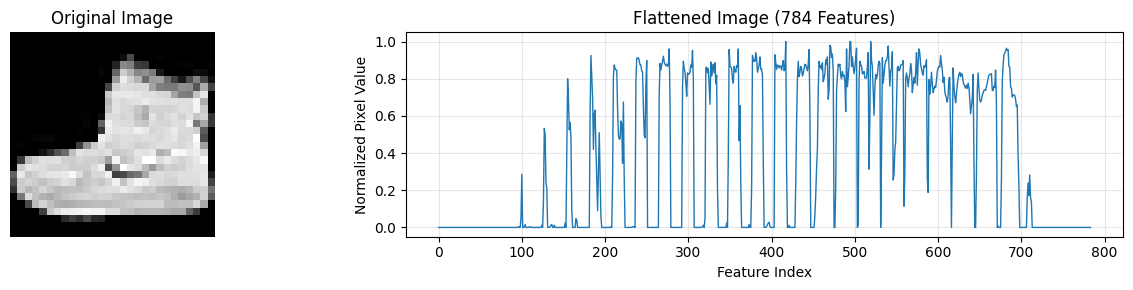


Data preprocessing completed successfully.


In [4]:
# ============================================================
# TASK 2 : DATA PREPROCESSING
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

print("="*60)
print("TASK 2 : DATA PREPROCESSING")
print("="*60)

# ------------------------------------------------------------
# Shapes Before Preprocessing
# ------------------------------------------------------------

print("\nShapes Before Preprocessing")
print("-"*40)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

# ------------------------------------------------------------
# Flatten Images
# ------------------------------------------------------------

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# ------------------------------------------------------------
# Normalize Pixel Values
# ------------------------------------------------------------

X_train_flat = X_train_flat.astype("float32") / 255.0
X_test_flat = X_test_flat.astype("float32") / 255.0

# ------------------------------------------------------------
# One-Hot Encode Labels
# ------------------------------------------------------------

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# ------------------------------------------------------------
# Shapes After Preprocessing
# ------------------------------------------------------------

print("\nShapes After Preprocessing")
print("-"*40)

print(f"X_train_flat : {X_train_flat.shape}")
print(f"X_test_flat  : {X_test_flat.shape}")
print(f"y_train_cat  : {y_train_cat.shape}")
print(f"y_test_cat   : {y_test_cat.shape}")

# ------------------------------------------------------------
# Pixel Statistics After Normalization
# ------------------------------------------------------------

print("\nNormalized Pixel Statistics")
print("-"*40)

print("Minimum :", X_train_flat.min())
print("Maximum :", X_train_flat.max())
print("Mean    :", X_train_flat.mean())
print("Std Dev :", X_train_flat.std())

# ------------------------------------------------------------
# Verify One-Hot Encoding
# ------------------------------------------------------------

print("\nExample Label Encoding")
print("-"*40)

print("Original Label :", y_train[0])
print("One-Hot Vector :")
print(y_train_cat[0])

# ------------------------------------------------------------
# Visualize Flattened Image
# ------------------------------------------------------------

sample_index = 0

plt.figure(figsize=(14, 3))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(X_train[sample_index], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Flattened Vector
plt.subplot(1, 2, 2)
plt.plot(X_train_flat[sample_index], linewidth=1)
plt.title("Flattened Image (784 Features)")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Pixel Value")
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "diagrams/task2_flattened_image.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nData preprocessing completed successfully.")

In [5]:
# ============================================================
# TASK 3 : MODEL CONSTRUCTION
# ============================================================

import os
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import plot_model

print("="*60)
print("TASK 3 : MODEL CONSTRUCTION")
print("="*60)

# ------------------------------------------------------------
# Build Baseline MLP
# ------------------------------------------------------------

model = Sequential([
    
    Input(shape=(784,), name="Input_Layer"),
    
    Dense(
        units=128,
        activation="relu",
        name="Hidden_Layer_1"
    ),
    
    Dense(
        units=64,
        activation="relu",
        name="Hidden_Layer_2"
    ),
    
    Dense(
        units=10,
        activation="softmax",
        name="Output_Layer"
    )
])

# ------------------------------------------------------------
# Display Model Summary
# ------------------------------------------------------------

print("\nMODEL SUMMARY\n")

model.summary()

# ------------------------------------------------------------
# Save Model Summary
# ------------------------------------------------------------

summary_file = "diagrams/task3_model_summary.txt"

with open(summary_file, "w") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

print(f"\nModel summary saved to: {summary_file}")

# ------------------------------------------------------------
# Generate Model Architecture Diagram
# ------------------------------------------------------------

try:

    plot_model(
        model,
        to_file="diagrams/task3_model_architecture.png",
        show_shapes=True,
        show_layer_names=True,
        dpi=300
    )

    # Convert PNG -> EPS
    img = plt.imread("diagrams/task3_model_architecture.png")

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.axis("off")

    plt.savefig(
        "diagrams/task3_model_architecture.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.close()

    print("Model architecture diagram saved successfully.")

except Exception as e:

    print("\nArchitecture diagram could not be generated.")
    print("Reason:", e)
    print("Install Graphviz if you want the architecture diagram.")

# ------------------------------------------------------------
# Print Network Information
# ------------------------------------------------------------

print("\nNetwork Configuration")
print("-"*40)

print("Input Neurons     : 784")
print("Hidden Layer 1    : 128 (ReLU)")
print("Hidden Layer 2    : 64 (ReLU)")
print("Output Neurons    : 10 (Softmax)")

print("\nTotal Layers :", len(model.layers))

print("\nBaseline MLP Model Created Successfully.")

TASK 3 : MODEL CONSTRUCTION


I0000 00:00:1784724958.870688      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



MODEL SUMMARY



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Model summary saved to: diagrams/task3_model_summary.txt
Model architecture diagram saved successfully.

Network Configuration
----------------------------------------
Input Neurons     : 784
Hidden Layer 1    : 128 (ReLU)
Hidden Layer 2    : 64 (ReLU)
Output Neurons    : 10 (Softmax)

Total Layers : 3

Baseline MLP Model Created Successfully.


TASK 4 : MODEL TRAINING

Model Compiled Successfully
Optimizer : Adam
Loss      : Categorical Crossentropy
Metric    : Accuracy
Epoch 1/20
  57/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4334 - loss: 1.5519

I0000 00:00:1784724966.421514     135 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8186 - loss: 0.5124 - val_accuracy: 0.8243 - val_loss: 0.4838
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8646 - loss: 0.3739 - val_accuracy: 0.8727 - val_loss: 0.3467
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8756 - loss: 0.3353 - val_accuracy: 0.8735 - val_loss: 0.3562
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8854 - loss: 0.3104 - val_accuracy: 0.8777 - val_loss: 0.3428
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8912 - loss: 0.2909 - val_accuracy: 0.8787 - val_loss: 0.3363
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8942 - loss: 0.2801 - val_accuracy: 0.8812 - val_loss: 0.3297
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9001 - loss: 0.2669 - val_accuracy: 0.8853 - val_loss: 0.3292
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9043 - loss: 0.2550 - val_accurac

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Training Completed Successfully

Training Time : 104.26 seconds

Final Training Accuracy   : 0.9356
Final Validation Accuracy : 0.8939
Final Training Loss       : 0.1727
Final Validation Loss     : 0.3466


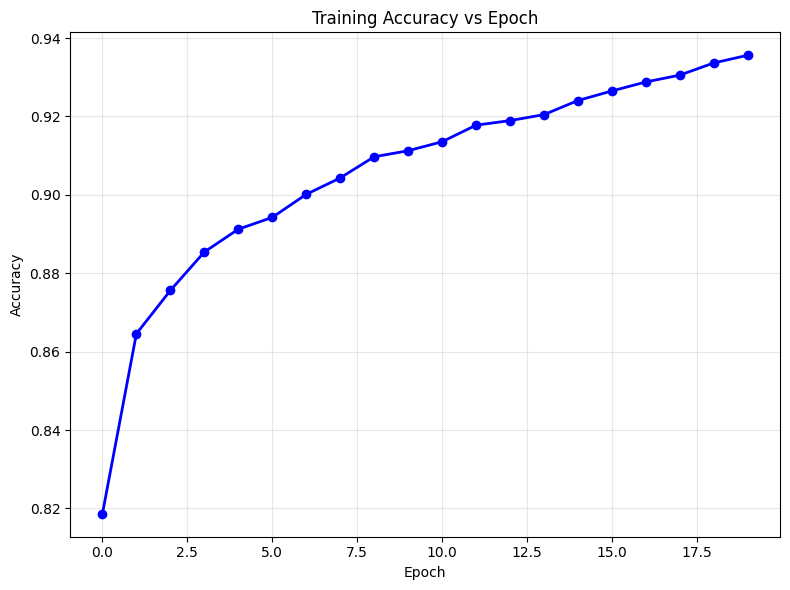

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


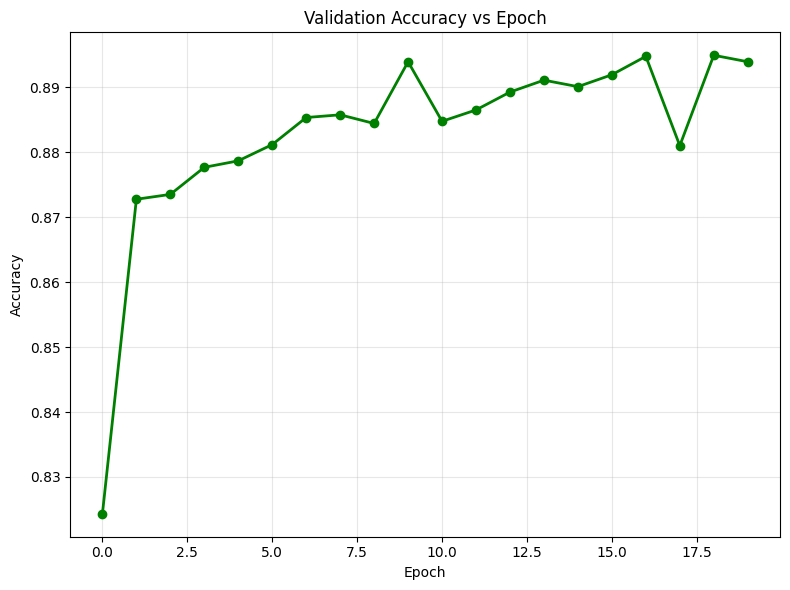

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


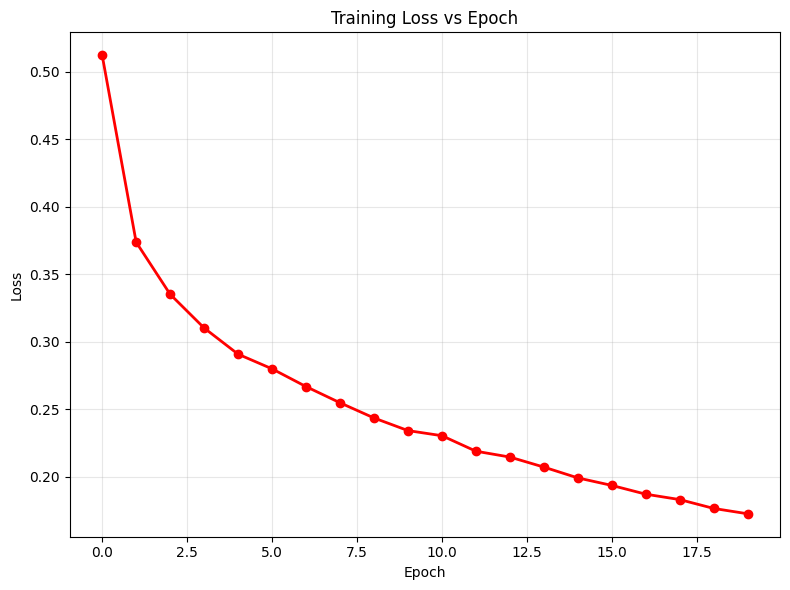

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


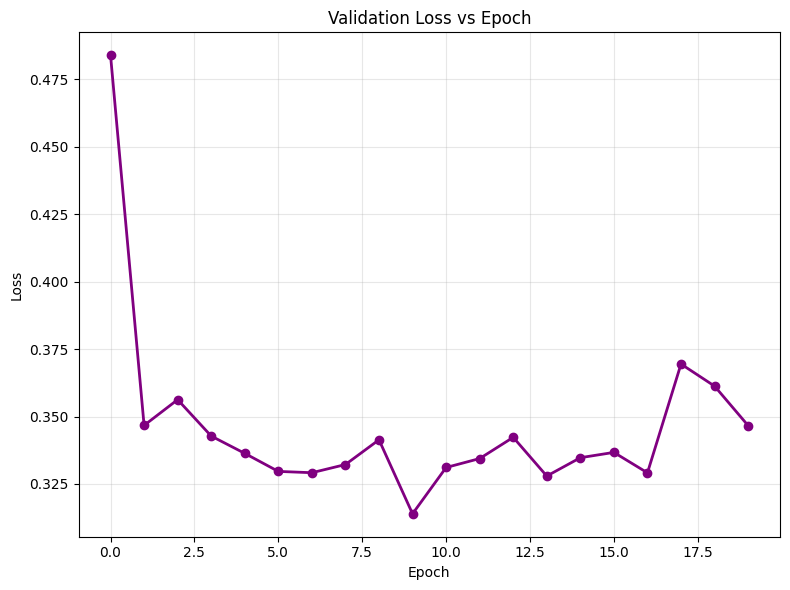


Baseline MLP training completed successfully.


In [6]:
# ============================================================
# TASK 4 : MODEL TRAINING
# ============================================================

import time
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

print("="*60)
print("TASK 4 : MODEL TRAINING")
print("="*60)

# ------------------------------------------------------------
# Compile Model
# ------------------------------------------------------------

model.compile(
    optimizer=Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel Compiled Successfully")
print("Optimizer : Adam")
print("Loss      : Categorical Crossentropy")
print("Metric    : Accuracy")

# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

start_time = time.time()

history = model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.20,
    epochs=20,
    batch_size=32,
    verbose=1
)

end_time = time.time()

baseline_training_time = end_time - start_time

print("\nTraining Completed Successfully")

print(f"\nTraining Time : {baseline_training_time:.2f} seconds")

# ------------------------------------------------------------
# Final Training Statistics
# ------------------------------------------------------------

print("\nFinal Training Accuracy   : {:.4f}".format(
    history.history["accuracy"][-1]
))

print("Final Validation Accuracy : {:.4f}".format(
    history.history["val_accuracy"][-1]
))

print("Final Training Loss       : {:.4f}".format(
    history.history["loss"][-1]
))

print("Final Validation Loss     : {:.4f}".format(
    history.history["val_loss"][-1]
))

# ============================================================
# Plot 1 : Training Accuracy
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["accuracy"],
    marker='o',
    linewidth=2,
    color='blue'
)

plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "diagrams/task4_training_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Plot 2 : Validation Accuracy
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["val_accuracy"],
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "diagrams/task4_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Plot 3 : Training Loss
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["loss"],
    marker='o',
    linewidth=2,
    color='red'
)

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "diagrams/task4_training_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Plot 4 : Validation Loss
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    history.history["val_loss"],
    marker='o',
    linewidth=2,
    color='purple'
)

plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "diagrams/task4_validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nBaseline MLP training completed successfully.")

TASK 5 : MODEL EVALUATION

Baseline Model Performance
---------------------------------------------
Accuracy : 0.8861
Precision: 0.8857
Recall   : 0.8861
F1-Score : 0.8852


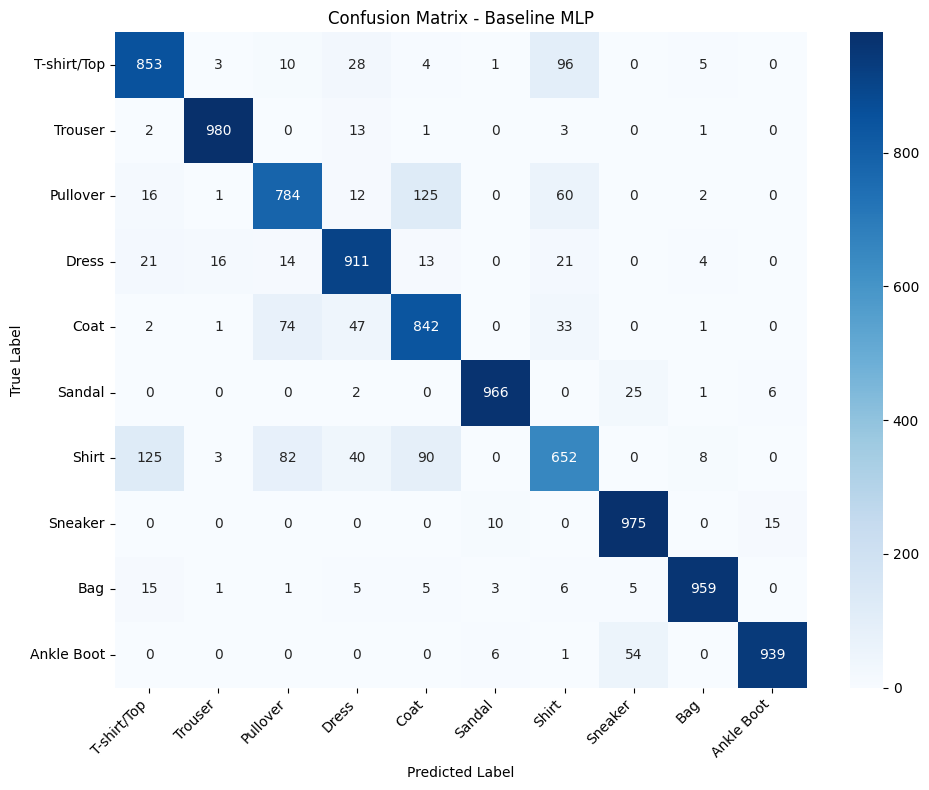


Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/Top     0.8250    0.8530    0.8387      1000
     Trouser     0.9751    0.9800    0.9776      1000
    Pullover     0.8124    0.7840    0.7980      1000
       Dress     0.8611    0.9110    0.8853      1000
        Coat     0.7796    0.8420    0.8096      1000
      Sandal     0.9797    0.9660    0.9728      1000
       Shirt     0.7477    0.6520    0.6966      1000
     Sneaker     0.9207    0.9750    0.9471      1000
         Bag     0.9776    0.9590    0.9682      1000
  Ankle Boot     0.9781    0.9390    0.9582      1000

    accuracy                         0.8861     10000
   macro avg     0.8857    0.8861    0.8852     10000
weighted avg     0.8857    0.8861    0.8852     10000


Classification report saved successfully.
Performance metrics saved successfully.

Baseline Model Evaluation Completed Successfully.


In [7]:
# ============================================================
# TASK 5 : MODEL EVALUATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("="*60)
print("TASK 5 : MODEL EVALUATION")
print("="*60)

# ------------------------------------------------------------
# Predict Test Dataset
# ------------------------------------------------------------

y_pred_prob = model.predict(X_test_flat, verbose=0)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

baseline_accuracy = accuracy_score(y_true, y_pred)

baseline_precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

baseline_recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

baseline_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("\nBaseline Model Performance")
print("-"*45)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Baseline MLP")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "diagrams/task5_confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report")
print("-"*70)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

# ------------------------------------------------------------
# Save Classification Report
# ------------------------------------------------------------

with open("diagrams/task5_classification_report.txt", "w") as f:
    f.write(report)

print("\nClassification report saved successfully.")

# ------------------------------------------------------------
# Save Performance Metrics
# ------------------------------------------------------------

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ]
})

performance_df.to_csv(
    "diagrams/task5_baseline_metrics.csv",
    index=False
)

print("Performance metrics saved successfully.")

print("\nBaseline Model Evaluation Completed Successfully.")

In [8]:
!zip -r output_files.zip /kaggle/working/diagrams


  adding: kaggle/working/diagrams/ (stored 0%)
  adding: kaggle/working/diagrams/task1_class_distribution.eps (deflated 71%)
  adding: kaggle/working/diagrams/task3_model_summary.txt (deflated 83%)
  adding: kaggle/working/diagrams/task4_training_accuracy.eps (deflated 70%)
  adding: kaggle/working/diagrams/task3_model_architecture.eps (deflated 98%)
  adding: kaggle/working/diagrams/task4_validation_accuracy.eps (deflated 70%)
  adding: kaggle/working/diagrams/task4_training_loss.eps (deflated 72%)
  adding: kaggle/working/diagrams/task2_flattened_image.eps (deflated 99%)
  adding: kaggle/working/diagrams/task4_validation_loss.eps (deflated 72%)
  adding: kaggle/working/diagrams/task5_classification_report.txt (deflated 63%)
  adding: kaggle/working/diagrams/task3_model_architecture.png (deflated 15%)
  adding: kaggle/working/diagrams/task5_baseline_metrics.csv (deflated 13%)
  adding: kaggle/working/diagrams/task5_confusion_matrix.eps (deflated 99%)
  adding: kaggle/working/diagrams/

In [9]:
from IPython.display import FileLink
FileLink(r'output_files.zip')


/kaggle/working/output_files.zip

In [10]:
# ============================================================
# HYPERPARAMETER OPTIMIZATION
# TASK 1 : USE THE BASELINE MLP MODEL
# ============================================================

print("=" * 70)
print("HYPERPARAMETER OPTIMIZATION - TASK 1")
print("Build a Baseline MLP Model")
print("=" * 70)

# ------------------------------------------------------------
# Verify that the baseline model already exists
# ------------------------------------------------------------

try:
    model
except NameError:
    raise Exception(
        "Baseline model not found.\n"
        "Please execute Tasks 1 to 5 before starting "
        "Hyperparameter Optimization."
    )

# ------------------------------------------------------------
# Store the trained baseline model
# ------------------------------------------------------------

baseline_model = model

# ------------------------------------------------------------
# Store baseline performance metrics
# ------------------------------------------------------------

baseline_metrics = {
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-Score": baseline_f1,
    "Training Time (s)": baseline_training_time
}

# ------------------------------------------------------------
# Display baseline metrics
# ------------------------------------------------------------

print("\nBaseline Model Successfully Loaded\n")

print(f"Accuracy        : {baseline_metrics['Accuracy']:.4f}")
print(f"Precision       : {baseline_metrics['Precision']:.4f}")
print(f"Recall          : {baseline_metrics['Recall']:.4f}")
print(f"F1-Score        : {baseline_metrics['F1-Score']:.4f}")
print(f"Training Time   : {baseline_metrics['Training Time (s)']:.2f} seconds")

print("\nBaseline model is ready for Hyperparameter Optimization.")

HYPERPARAMETER OPTIMIZATION - TASK 1
Build a Baseline MLP Model

Baseline Model Successfully Loaded

Accuracy        : 0.8861
Precision       : 0.8857
Recall          : 0.8861
F1-Score        : 0.8852
Training Time   : 104.26 seconds

Baseline model is ready for Hyperparameter Optimization.


In [14]:
!pip install scikeras==0.13.0

  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)


In [15]:
# ============================================================
# HYPERPARAMETER OPTIMIZATION
# TASK 2 : DEFINE THE HYPERPARAMETER SEARCH SPACE
# ============================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from scikeras.wrappers import KerasClassifier

print("=" * 70)
print("HYPERPARAMETER OPTIMIZATION - TASK 2")
print("Define the Hyperparameter Search Space")
print("=" * 70)

# ------------------------------------------------------------
# Function to build an MLP model
# ------------------------------------------------------------
def build_mlp(
    hidden_layers=2,
    hidden_neurons=128,
    activation="relu",
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.0
):
    
    model = Sequential()
    model.add(Input(shape=(784,)))

    # Add hidden layers
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(10, activation="softmax"))

    # Select optimizer
    optimizers = {
        "adam": Adam(learning_rate=learning_rate),
        "sgd": SGD(learning_rate=learning_rate),
        "rmsprop": RMSprop(learning_rate=learning_rate)
    }

    model.compile(
        optimizer=optimizers[optimizer],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ------------------------------------------------------------
# Wrap the model using SciKeras
# ------------------------------------------------------------
mlp_classifier = KerasClassifier(
    model=build_mlp,
    verbose=0
)

# ------------------------------------------------------------
# Hyperparameter Search Space
# ------------------------------------------------------------
parameter_space = {

    "model__hidden_layers": [1, 2, 3],

    "model__hidden_neurons": [32, 64, 128, 256],

    "model__activation": [
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__optimizer": [
        "adam",
        "sgd",
        "rmsprop"
    ],

    "model__learning_rate": [
        0.1,
        0.01,
        0.001
    ],

    "model__dropout_rate": [
        0.0,
        0.2,
        0.5
    ],

    "batch_size": [
        16,
        32,
        64,
        128
    ],

    "epochs": [
        10,
        20,
        30
    ]
}

# ------------------------------------------------------------
# Display Search Space
# ------------------------------------------------------------
print("\nHyperparameter Search Space\n")

for parameter, values in parameter_space.items():
    print(f"{parameter:28s} : {values}")

print("\nSearch space successfully created.")
print("Ready to perform RandomizedSearchCV in Task 3.")

HYPERPARAMETER OPTIMIZATION - TASK 2
Define the Hyperparameter Search Space

Hyperparameter Search Space

model__hidden_layers         : [1, 2, 3]
model__hidden_neurons        : [32, 64, 128, 256]
model__activation            : ['relu', 'tanh', 'sigmoid']
model__optimizer             : ['adam', 'sgd', 'rmsprop']
model__learning_rate         : [0.1, 0.01, 0.001]
model__dropout_rate          : [0.0, 0.2, 0.5]
batch_size                   : [16, 32, 64, 128]
epochs                       : [10, 20, 30]

Search space successfully created.
Ready to perform RandomizedSearchCV in Task 3.


In [16]:
import sklearn, scikeras
print("scikit-learn:", sklearn.__version__)
print("scikeras:", scikeras.__version__)

scikit-learn: 1.6.1
scikeras: 0.13.0


In [17]:
# ============================================================
# HYPERPARAMETER OPTIMIZATION
# TASK 2 & 3 : DEFINE SEARCH SPACE + RANDOMIZED SEARCH (5-FOLD CV)
# (Manual implementation — avoids scikeras/scikit-learn version conflicts)
# ============================================================

import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.model_selection import KFold

print("=" * 70)
print("HYPERPARAMETER OPTIMIZATION - TASK 2")
print("Define the Hyperparameter Search Space")
print("=" * 70)

# ------------------------------------------------------------
# Function to build an MLP model
# ------------------------------------------------------------
def build_mlp(
    hidden_layers=2,
    hidden_neurons=128,
    activation="relu",
    optimizer="adam",
    learning_rate=0.001,
    dropout_rate=0.0
):
    model = Sequential()
    model.add(Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    optimizers = {
        "adam": Adam(learning_rate=learning_rate),
        "sgd": SGD(learning_rate=learning_rate),
        "rmsprop": RMSprop(learning_rate=learning_rate)
    }

    model.compile(
        optimizer=optimizers[optimizer],
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ------------------------------------------------------------
# Hyperparameter Search Space (as per lab manual, Section 7)
# ------------------------------------------------------------
parameter_space = {
    "hidden_layers": [1, 2, 3],
    "hidden_neurons": [32, 64, 128, 256],
    "activation": ["relu", "tanh", "sigmoid"],
    "optimizer": ["adam", "sgd", "rmsprop"],
    "learning_rate": [0.1, 0.01, 0.001],
    "dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

print("\nHyperparameter Search Space\n")
for parameter, values in parameter_space.items():
    print(f"{parameter:18s} : {values}")

print("\nSearch space successfully created.")

# ------------------------------------------------------------
# Search settings
# ------------------------------------------------------------
N_ITER   = 20   # number of random combinations to try
CV_FOLDS = 5    # 5-Fold Cross Validation (per lab manual)

random.seed(42)
np.random.seed(42)

# Randomly sample N_ITER combinations from the search space
sampled_combinations = []
for _ in range(N_ITER):
    combo = {key: random.choice(values) for key, values in parameter_space.items()}
    sampled_combinations.append(combo)

# ============================================================
# TASK 3 : RANDOMIZED SEARCH WITH 5-FOLD CROSS VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("HYPERPARAMETER OPTIMIZATION - TASK 3")
print("Randomized Search using 5-Fold Cross Validation (manual loop)")
print("=" * 70)

print(f"\nStarting Randomized Search... ({N_ITER} combinations x {CV_FOLDS} folds)\n")

search_start_time = time.time()

results_records = []
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

for i, params in enumerate(sampled_combinations, start=1):

    fold_accuracies = []

    for fold_index, (train_idx, val_idx) in enumerate(kf.split(X_train_flat), start=1):

        X_tr, X_val = X_train_flat[train_idx], X_train_flat[val_idx]
        y_tr, y_val = y_train_cat[train_idx], y_train_cat[val_idx]

        tf.keras.backend.clear_session()

        fold_model = build_mlp(
            hidden_layers=params["hidden_layers"],
            hidden_neurons=params["hidden_neurons"],
            activation=params["activation"],
            optimizer=params["optimizer"],
            learning_rate=params["learning_rate"],
            dropout_rate=params["dropout_rate"]
        )

        fold_model.fit(
            X_tr, y_tr,
            batch_size=params["batch_size"],
            epochs=params["epochs"],
            verbose=0
        )

        val_loss, val_accuracy = fold_model.evaluate(X_val, y_val, verbose=0)
        fold_accuracies.append(val_accuracy)

    mean_cv_accuracy = float(np.mean(fold_accuracies))
    std_cv_accuracy = float(np.std(fold_accuracies))

    record = dict(params)
    record["mean_cv_accuracy"] = mean_cv_accuracy
    record["std_cv_accuracy"] = std_cv_accuracy
    results_records.append(record)

    print(f"[{i:02d}/{N_ITER}] acc = {mean_cv_accuracy:.4f} (+/- {std_cv_accuracy:.4f}) | {params}")

search_end_time = time.time()
search_time = search_end_time - search_start_time

# ------------------------------------------------------------
# Identify Best Combination
# ------------------------------------------------------------
search_results = pd.DataFrame(results_records)
search_results = search_results.sort_values("mean_cv_accuracy", ascending=False).reset_index(drop=True)

best_row = search_results.iloc[0]
best_parameters = {k: best_row[k] for k in parameter_space.keys()}
best_cv_accuracy = best_row["mean_cv_accuracy"]

print("\nRandomized Search Completed Successfully.\n")
print("Best Cross Validation Accuracy : {:.4f}".format(best_cv_accuracy))

print("\nBest Hyperparameters\n")
for parameter, value in best_parameters.items():
    print(f"{parameter:18s} : {value}")

print("\nSearch Time : {:.2f} seconds".format(search_time))

# ------------------------------------------------------------
# Save Complete Search Results
# ------------------------------------------------------------
search_results.to_csv("diagrams/task6_random_search_results.csv", index=False)

print("\nSearch results saved to:")
print("diagrams/task6_random_search_results.csv")

# ------------------------------------------------------------
# Save Best Hyperparameters
# ------------------------------------------------------------
best_parameter_table = pd.DataFrame({
    "Hyperparameter": list(best_parameters.keys()),
    "Best Value": list(best_parameters.values())
})
best_parameter_table.to_csv("diagrams/task6_best_hyperparameters.csv", index=False)

print("Best hyperparameters saved to:")
print("diagrams/task6_best_hyperparameters.csv")

print("\nTasks 2 & 3 completed successfully.")
print("Proceed to the next task: Retrain the model using the optimized hyperparameters.")

HYPERPARAMETER OPTIMIZATION - TASK 2
Define the Hyperparameter Search Space

Hyperparameter Search Space

hidden_layers      : [1, 2, 3]
hidden_neurons     : [32, 64, 128, 256]
activation         : ['relu', 'tanh', 'sigmoid']
optimizer          : ['adam', 'sgd', 'rmsprop']
learning_rate      : [0.1, 0.01, 0.001]
dropout_rate       : [0.0, 0.2, 0.5]
batch_size         : [16, 32, 64, 128]
epochs             : [10, 20, 30]

Search space successfully created.

HYPERPARAMETER OPTIMIZATION - TASK 3
Randomized Search using 5-Fold Cross Validation (manual loop)

Starting Randomized Search... (20 combinations x 5 folds)

[01/20] acc = 0.8239 (+/- 0.0117) | {'hidden_layers': 3, 'hidden_neurons': 32, 'activation': 'relu', 'optimizer': 'rmsprop', 'learning_rate': 0.01, 'dropout_rate': 0.0, 'batch_size': 32, 'epochs': 10}
[02/20] acc = 0.8587 (+/- 0.0051) | {'hidden_layers': 3, 'hidden_neurons': 32, 'activation': 'sigmoid', 'optimizer': 'rmsprop', 'learning_rate': 0.001, 'dropout_rate': 0.0, 'batch